  Flight Number            Airline  Delay
0        FN1001            JetBlue     75
1        FN1002          Southwest     75
2        FN1003  American Airlines     53
3        FN1004          Southwest    136
4        FN1005            JetBlue     56


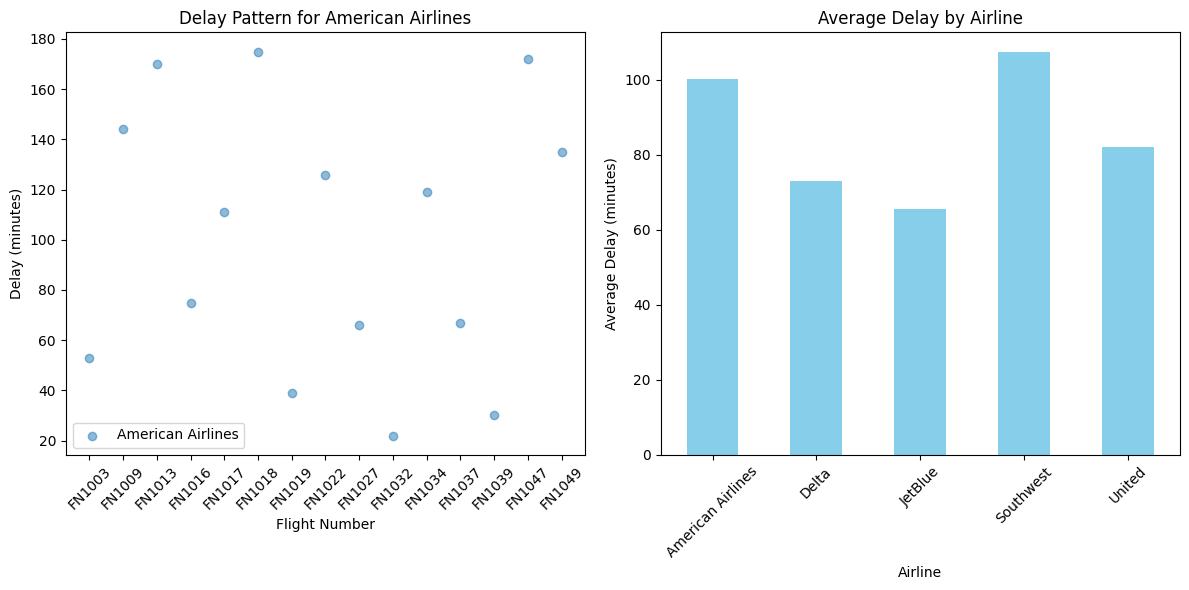

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import ttk, filedialog

# Global variable for DataFrame
df = None

# Load Data Function
def load_data():
    global df
    file_path = filedialog.askopenfilename(title="Select Flight Data CSV File", filetypes=[("CSV files", "*.csv")])
    
    if file_path:
        try:
            df = pd.read_csv(file_path)
            print(df.head())  # Debugging: Print first few rows
            
            # Check if required columns exist
            required_columns = {'Airline', 'Delay', 'Flight Number'}
            if not required_columns.issubset(df.columns):
                status_label.config(text="Missing required columns!", fg="red")
                print("Available columns:", df.columns)
                return

            status_label.config(text="Data Loaded Successfully", fg="green")

            # Populate airline dropdown
            airlines = df['Airline'].dropna().unique()
            airline_dropdown['values'] = list(airlines)
            airline_dropdown.current(0)  # Select the first airline

        except Exception as e:
            status_label.config(text="Error loading file!", fg="red")
            print("Error:", e)

# Calculate Delays Function
def calculate_delays():
    if df is None:
        status_label.config(text="No data loaded!", fg="red")
        return

    delay_avg = df.groupby('Airline')['Delay'].mean()
    on_time_percentage = (df['Delay'] == 0).sum() / len(df) * 100

    result_text.set(f"Avg Delay by Airline:\n{delay_avg}\n\nOn-time Flights: {on_time_percentage:.2f}%")

# Generate Scatter Plot Function
def plot_delays():
    if df is None:
        status_label.config(text="No data loaded!", fg="red")
        return

    selected_airline = airline_var.get()
    if not selected_airline:
        status_label.config(text="Select an airline first!", fg="red")
        return

    airline_data = df[df['Airline'] == selected_airline]
    
    # Scatter plot
    plt.figure(figsize=(12,6))
    
    plt.subplot(1, 2, 1)  # Create a subplot (1 row, 2 columns, first plot)
    plt.scatter(airline_data['Flight Number'], airline_data['Delay'], alpha=0.5, label=selected_airline)
    plt.xlabel('Flight Number')
    plt.ylabel('Delay (minutes)')
    plt.title(f'Delay Pattern for {selected_airline}')
    plt.legend()
    plt.xticks(rotation=45)

    # Bar plot for average delay by airline
    delay_avg = df.groupby('Airline')['Delay'].mean()
    plt.subplot(1, 2, 2)  # Second plot in the same row
    delay_avg.plot(kind='bar', color='skyblue', ax=plt.gca())
    plt.title('Average Delay by Airline')
    plt.xlabel('Airline')
    plt.ylabel('Average Delay (minutes)')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

# Create GUI
root = tk.Tk()
root.title("Flight Delay Analyzer")
root.geometry("400x350")

# Load Data Button
load_button = tk.Button(root, text="Load Flight Data", command=load_data)
load_button.pack(pady=5)

# Status Label
status_label = tk.Label(root, text="No Data Loaded", fg="red")
status_label.pack()

# Airline Selection Dropdown
airline_var = tk.StringVar()
airline_dropdown = ttk.Combobox(root, textvariable=airline_var, state="readonly")
airline_dropdown.pack(pady=5)

# Calculate Delays Button
calc_button = tk.Button(root, text="Calculate Delays", command=calculate_delays)
calc_button.pack(pady=5)

# Display Results
result_text = tk.StringVar()
result_label = tk.Label(root, textvariable=result_text, justify="left")
result_label.pack(pady=5)

# Plot Delays Button
plot_button = tk.Button(root, text="Show Delay Plot", command=plot_delays)
plot_button.pack(pady=5)

# Run GUI
root.mainloop()
